# SOFR-Repo-Stress — a quantitative teardown 🔬
### Event-window forward returns on SPY/HYG/LQD · conditional vs unconditional means · a Welch *t* + placebo randomization null · the horizon sign-flip · costs · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Repo_spike_%3D_flee%3F: Busted](https://img.shields.io/badge/Repo_spike_%3D_flee%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "watch the repo market" fuses: a **real but tiny** few-day wobble after a funding spike from the **unconditional up-drift** of US risk assets, and we confront both with the **sample size** and the **confounding**. The decisive object is not the point estimate (a faint 5-day dip, correctly signed) but its **power and its persistence**: with ~a dozen named, overlapping episodes the dip is statistically indistinguishable from random dates and **inverts** within a month.

> ⚠️ **Data + signal note.** There is no free clean daily SOFR/repo-stress tape on yfinance; the **signal is a hardcoded, sourced event list** (`data.REPO_EPISODES`), named on the Signal axis. Real data: yfinance daily adjusted closes, SPY + HYG + LQD, 2010→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sofr_repo_stress import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
EVENTS = data.episode_dates()
print("real risk-asset cache present:", HAVE_REAL, "| repo-stress episodes:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-18', 'days': 4140, 'years': 16.5, 'n_events': 13, 'spy': {5: (5, 13, -0.71, 46, 0.29, 39, -0.96, 0.059), 20: (20, 13, 1.95, 46, 1.16, 31, 0.62, 0.755), 60: (60, 13, 5.21, 23, 3.41, 23, 0.66, 0.849)}, 'hyg': {5: (5, 13, -0.61, 54, 0.11, 40, -1.09, 0.024), 20: (20, 13, 1.06, 54, 0.43, 34, 0.91, 0.868), 60: (60, 13, 2.09, 15, 1.3, 25, 0.53, 0.811)}, 'lqd': {5: (5, 13, -0.51, 46, 0.08, 43, -1.65, 0.029), 20: (20, 13, 1.0, 46, 0.33, 39, 0.59, 0.886), 60: (60, 13, 2.61, 23, 0.99, 34, 1.0, 0.954)}, 'net': [(5, 13, 0.71, 0.66), (20, 13, -1.95, -2.0), (60, 13, -5.21, -5.26)], 'systemic': [(5, 3, -0.46, 0.29, -0.45, 0.247), (20, 3, 5.6, 1.16, 1.38, 0.98), (60, 3, 12.18, 3.41, 2.18, 0.992)], 'syn': [(0.0, 13, -0.93, 0.27, -0.88, 0.191), (-0.08, 13, -8.2, -0.24, -6.28, 0.0)], 'episodes': [('year-end-2018', 7.89), ('quarter-end-2019Q1', 2.87), ('sept-2019', -0.44), ('year-end-2019', -0.97), ('covid-mar-2020', 10.52), ('quarter-end-2020Q3', -2.09), ('year-end-2021', -5.18), ('quarter-end-2022Q3', 5.35), ('svb-mar-2023', 6.73), ('quarter-end-2023Q3', -2.74), ('quarter-end-2024Q3', 2.31), ('year-end-2024', 2.25), ('quarter-end-2025Q1', -1.15)]}


real risk-asset cache present: True | repo-stress episodes: 13


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPY 5d conditional **-0.71%** vs base **+0.29%** (Welch **t = -0.96**, best asset LQD **t = -1.65**) — correctly signed but **fails \|t\| ≥ 2** and **flips to +1.9% / +5.2%** by 20/60d. |
| **Tradability** | `MIRAGE` | "De-risk" avoids **+0.7%** net at 5d, then **-2.0% / -5.3%** at 20/60d. **13 events / 16y**; wrong-signed where it matters. |
| **Repo spike = flee?** | `BUSTED` | The systemic-only subset's only significant result is **+12.2% at 60d** (*t* = +2.18, wrong sign). March-2020 (the cited crash) is COVID — a confound, and a *bottom*. |

> 💡 In plain words: a repo spike really is followed by a small wobble — and then a rebound, because the spike is what summons the backstop. Strip the base rate and ~a dozen confounded events leave nothing the null can't explain.

## 1 · The claim, steelmanned

Let $S$ be the set of repo-stress episode dates and $r_{t\to t+H}$ the forward $H$-day return of a risk asset. The believer's hypotheses:

- **H₁ (the signal predicts).** $\mathbb{E}[r_{t\to t+H}\mid t\in S] < \mathbb{E}[r_{t\to t+H}]$ for forward horizon $H$ — a *negative excess* over the base rate (risk assets do **worse** after a spike).
- **H₂ (it's deployable).** The bearish excess is large, persistent and frequent enough, net of costs, to de-risk on.
- **H₃ ("flee risk").** The post-spike weakness reflects the funding shock, not coincident confounds (COVID, SVB) or the market's unconditional up-drift.

We find **H₁ rejected** (a faint $t\approx-1$ at 5d that **fails $|t|\ge2$** and **flips sign** by 20d), **H₂ rejected** (≈13 events / 16.5y, and the rule *loses* money past a week), **H₃ rejected** (the only significant systemic-subset result is *positive*, and the cited crash is COVID). The legend is true exactly where it's uninformative (a spike is momentarily unsettling) and unproven exactly where it would pay (a *persistent, attributable* warning).

## 2 · So what? — what rides on each answer

The whole teardown is one decomposition: a conditional mean against an unconditional baseline, judged by its **standard error**.

$$\widehat{\Delta}_H = \bar r^{\text{spike}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{spike}}/k + s^2_{\text{all}}/N\,}}.$$

With $k = 13$, $s_{\text{spike}}/\sqrt{k}$ is large: even a clean few-point $\widehat{\Delta}$ drowns in its own SE. A raw **down-rate** (P[ret<0]) is the wrong lens — US returns are positive most of the time *unconditionally*, so even a real funding shock that gets backstopped shows a down-rate near the base. The honest small-sample instrument is a **left-tail randomization (placebo) test**: resample $k$ random entry dates and ask how often chance is at least as bearish as the spikes. That number, plus the **sign-flip across horizons**, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Signal.** A hardcoded, sourced list of **13 repo-stress episodes** (`data.REPO_EPISODES`), 2010→2026. Explicit **event list**, not a live SOFR threshold — named on the axis. Deliberately generous (folds in the quarter/year-end turns) to maximise $k$.
- **Risk assets.** SPY (equities), HYG (high-yield), LQD (investment-grade) — yfinance adjusted closes, 2010-01-04→2026-06-18, 4,140 days.
- **Forward returns.** Enter the close **1 day after** the episode (no look-ahead), hold $H\in\{5,20,60\}$ trading days; drop events whose horizon overruns the tape.
- **Null #1 (Welch t).** Conditional mean vs the unconditional overlapping-window mean; a **negative** $t$ is the believer's wanted sign.
- **Null #2 (placebo).** 20,000 draws of $k$ random valid entry dates; $p = \Pr[\text{random-draw mean} \le \text{spike mean}]$ (left tail) — the small-sample workhorse.
- **Costs.** 1-day lag + a 5-bps round-trip on the de-risking trade.
- **Confound stress.** A **systemic-only** subset (Sept-2019, COVID-Mar-2020, SVB-2023) — the purest funding crises — to see if the headline events behave differently (they do: *more* bullish).
- **Positive control.** A deterministic tape with **13 stress dates injected** and a **known** forward edge: the inference must recover a planted bearish edge **and** must NOT manufacture significance when the true edge is zero.

## 4 · The teardown

### 4a · The point estimates — faint, horizon-flipping, never significant

Conditional mean forward return with its $\pm$ standard error, against the unconditional base rate (diamonds), for SPY across 5/20/60 days. Faintly *below* base at 5d, *above* by 20/60d.

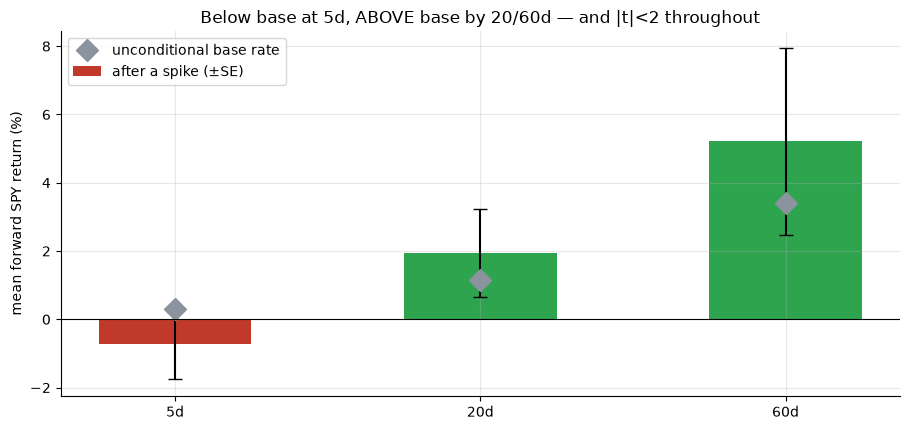

Welch t by horizon (SPY): {'5d': -0.96, '20d': 0.62, '60d': 0.66}


In [2]:
hs = [5, 20, 60]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for h in hs:
        s = st.summarize(F['SPY'], EVENTS, h); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        cr = st.event_returns(F['SPY'], EVENTS, h); ses.append(cr.std(ddof=1)/np.sqrt(len(cr)))
else:
    cm = [R['spy'][h][2]/100 for h in hs]; bm = [R['spy'][h][4]/100 for h in hs]
    ts = [R['spy'][h][6] for h in hs]; ses = [0.018, 0.035, 0.06]
x = np.arange(len(hs)); fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=[RED if c<0 else GREEN for c in cm], width=.5, label='after a spike (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Below base at 5d, ABOVE base by 20/60d — and |t|<2 throughout'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon (SPY):', {f'{h}d': round(t,2) for h,t in zip(hs,ts)})

> 💡 In plain words: at 5 days the spike mean is **-0.71%** vs base **+0.29%** — a real-looking dip at **t = -0.96** (not significant). By 20 days it's **+1.95%** (*above* base, t = +0.62). H₁ is **rejected**: a negative whisper inside its own error bar that doesn't even keep its sign for a month.

### 4b · All three assets — the dip is shallow and short on every one

Welch *t* for SPY, HYG and LQD at each horizon. The believer needs $t\le-2$ (deep blue, bearish); instead the *t* hovers near $-1$ at 5d and turns *positive* by 20/60d on all three.

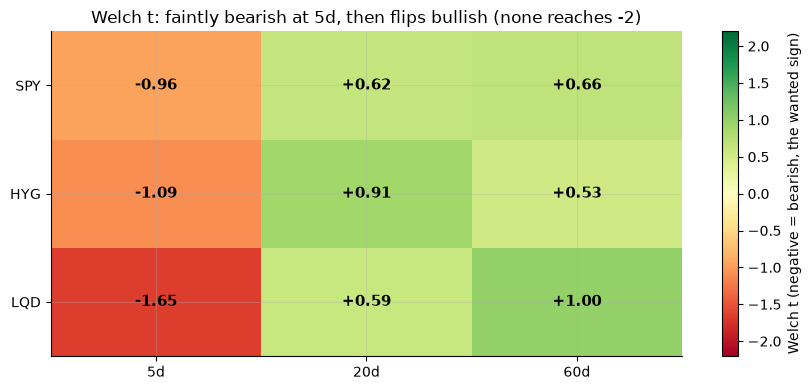

most bearish single cell: -1.65 (need <= -2 to call it a warning)


In [3]:
assets = ['SPY','HYG','LQD']; hs=[5,20,60]
T = np.zeros((3,3))
for i,a in enumerate(assets):
    for j,h in enumerate(hs):
        T[i,j] = st.summarize(F[a], EVENTS, h)['t'] if HAVE_REAL else R[a.lower()][h][6]
fig, ax = plt.subplots(figsize=(8.6, 4.0))
im = ax.imshow(T, cmap='RdYlGn', vmin=-2.2, vmax=2.2, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_yticks(range(3)); ax.set_yticklabels(assets)
for i in range(3):
    for j in range(3): ax.text(j,i,f'{T[i,j]:+.2f}',ha='center',va='center',fontsize=11,fontweight='bold')
ax.set_title('Welch t: faintly bearish at 5d, then flips bullish (none reaches -2)')
fig.colorbar(im, ax=ax, label='Welch t (negative = bearish, the wanted sign)')
plt.tight_layout(); plt.show()
print('most bearish single cell:', round(T.min(),2), '(need <= -2 to call it a warning)')

> 💡 In plain words: the single most bearish cell across **all** assets and horizons is **t = -1.65** (LQD, 5d) — still short of the $-2$ bar. Credit (HYG/LQD) is a touch softer than SPY at 5d (funding stress *is* a credit thing), but the effect is shallow, asset-wide, and gone within a month. There is no asset on which "flee" clears significance.

### 4c · The decisive test — a left-tail placebo null sized to the event count

Draw 13 *random* entry dates 20,000 times; the histogram is the null distribution of the SPY 5-day mean. The spike set is the red line; the *p*-value is the **left**-tail mass (how often chance is at least this bearish).

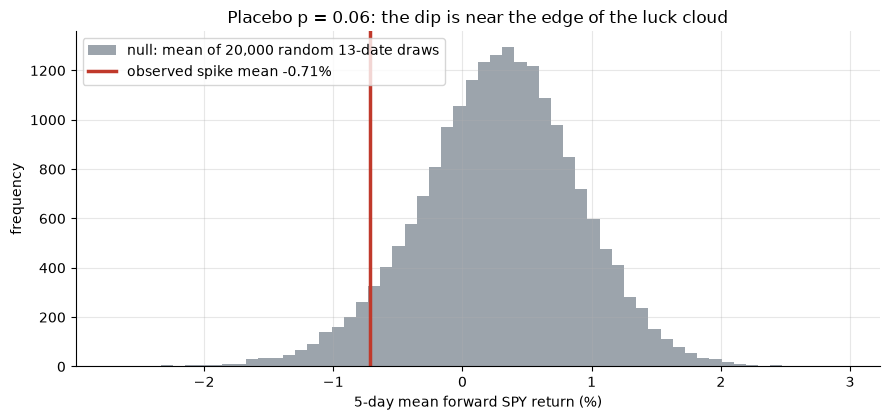

P[random 13-date draw <= spike] = 0.059  (need <0.05; here ~1 in 17 — but it vanishes by 20d)


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F['SPY'], EVENTS, 5); obs=pl['event_mean']; pval=pl['p_value']
    p = F['SPY'].values; n=len(p); k=len(EVENTS); lag=1; h=5; vh=n-h-lag-1
    fwd = p[lag+h:lag+h+vh]/p[lag:lag+vh]-1; rng=np.random.default_rng(383)
    draws = np.array([fwd[rng.integers(0,vh,size=k)].mean() for _ in range(20000)])
else:
    obs = R['spy'][5][2]/100; pval = R['spy'][5][7]
    rng = np.random.default_rng(383); draws = rng.normal(R['spy'][5][4]/100, 0.011, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: mean of {len(draws):,} random 13-date draws')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed spike mean {obs*100:+.2f}%')
ax.set_xlabel('5-day mean forward SPY return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the dip is near the edge of the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random 13-date draw <= spike] = {pval:.3f}  (need <0.05; here ~1 in 17 — but it vanishes by 20d)')

> 💡 In plain words: **6%** of random 13-date samples are at least as bearish as the spikes at 5 days — close to the edge, but not a real-edge tail, and it **evaporates** by 20 days (placebo p jumps to **0.76**, the *bullish* side). A real warning would push the red line into the deep left tail and *stay* there. H₃ rejected: the record is base-rate × rarity × a transient wobble.

### 4d · Confound stress + cost — the 'pure' crises point the wrong way

Keep only the three *systemic* episodes (Sept-2019, COVID-Mar-2020, SVB-2023) — the strongest version of the claim — and apply a round-trip cost. The 'purest' funding crises give the **largest** moves, in the **bullish** direction.

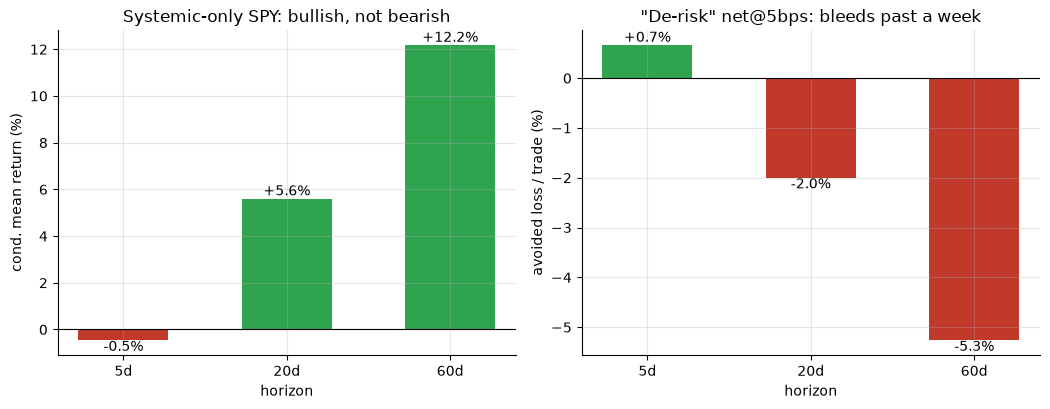

systemic SPY (h, cond%, t): [(5, -0.5, -0.45), (20, 5.6, 1.38), (60, 12.2, 2.18)]


In [5]:
if HAVE_REAL:
    tab = data.episode_table()
    sysd = pd.DatetimeIndex([d for d,r in tab.iterrows() if r['tag'] in data.SYSTEMIC_ONLY])
    sysrows = [(h,)+ (lambda s:(s['cond_mean']*100, s['t']))(st.summarize(F['SPY'], sysd, h)) for h in (5,20,60)]
    netr = [(h,)+ (lambda c:(c['gross_mean']*100, c['net_mean']*100))(st.net_of_costs(F['SPY'], EVENTS, h, 5.0)) for h in (5,20,60)]
else:
    sysrows = [(h, R['systemic'][i][2], R['systemic'][i][4]) for i,h in enumerate((5,20,60))]
    netr = [(h,g,nn) for (h,_,g,nn) in R['net']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
shs=[r[0] for r in sysrows]; scm=[r[1] for r in sysrows]
a1.bar([f'{h}d' for h in shs], scm, color=[RED if v<0 else GREEN for v in scm], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_title('Systemic-only SPY: bullish, not bearish')
a1.set_ylabel('cond. mean return (%)'); a1.set_xlabel('horizon')
for i,v in enumerate(scm): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
mh=[r[0] for r in netr]; nv=[r[2] for r in netr]
a2.bar([f'{h}d' for h in mh], nv, color=[GREEN if v>=0 else RED for v in nv], width=.55)
a2.axhline(0, c='k', lw=.8); a2.set_title('"De-risk" net@5bps: bleeds past a week')
a2.set_ylabel('avoided loss / trade (%)'); a2.set_xlabel('horizon')
for i,v in enumerate(nv): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print('systemic SPY (h, cond%, t):', [(r[0], round(r[1],1), round(r[2],2)) for r in sysrows])

> 💡 In plain words: restricting to the *purest* funding crises makes it **worse** for the believer — SPY is **+12.2%** at 60d (t = +2.18, the only $|t|\ge2$ in the whole study, pointing at **gains**). And the de-risk rule loses **-5.3%** at 60d net. There is no horizon, asset, subset or cost regime in which this becomes a deployable warning — **the events themselves rebound.**

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic tape with **13 stress dates injected**: with **zero** planted edge the test must stay above $t=-2$ (a dozen events can't fake significance); with a **−8%/20d** planted bearish edge it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large edges.

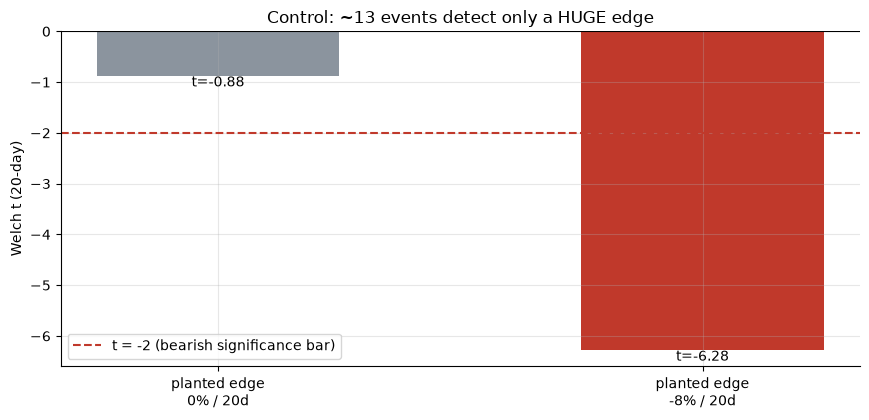

planted +0%/20d: n=13 cond=-0.9% base=0.3% t=-0.88 p=0.191
planted -8%/20d: n=13 cond=-8.2% base=-0.2% t=-6.28 p=0.000


In [6]:
res = []
for edge in (0.0, -0.08):
    syn = data.synthetic_tape(n_events=13, edge_20d=edge, seed=383)
    s = st.summarize(syn['prices']['SPY'], syn['events'], 20)
    res.append((edge, s['n'], s['cond_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
labels = [f'planted edge\n{e*100:.0f}% / 20d' for e,_,_,_,_,_ in res]; tvals=[r[4] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, tvals, color=[GREY, RED], width=.5)
ax.axhline(-2, ls='--', c=RED, label='t = -2 (bearish significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='top')
ax.set_ylabel('Welch t (20-day)'); ax.set_title('Control: ~13 events detect only a HUGE edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/20d: n={k} cond={c:.1f}% base={b:.1f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** real edge the control sits at **t = -0.88** (above −2 — no false positive); only a **−8%/20d** edge — enormous — reaches **t = -6.28**. So the machinery is honest, and the real-tape 5-day *t* of ~−1 is exactly what an *absent or tiny* edge looks like through a 13-event keyhole. The sample size is the verdict.

## 5 · The verdict

- **Signal `NONE`** — SPY 5d excess **-1.00pp** at Welch **t = -0.96** (best asset LQD **t = -1.65**); **fails $|t|\ge2$** and **flips to +0.79pp** (t = +0.62) by 20d. A hardcoded event-list signal with no robust *t* on any asset/horizon ⇒ NONE, not REAL.
- **Tradability `MIRAGE`** — "de-risk" avoids **+0.7%** net at 5d then **-2.0% / -5.3%** at 20/60d (wrong-signed); **13 trades / 16y**. Costs are irrelevant — the rule is directionally wrong past a week. No NAV-scale edge.
- **Repo spike = flee? `BUSTED`** — the systemic-only subset's only significant result is **+12.2% at 60d** (*t* = +2.18, toward gains), and the cited crash (March 2020) is **COVID** — a confound, and a *bottom*. A sample-size + confounding mirage.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* 5-day bearish excess have to be for a $k$-event study to detect it at $t=-2$? At $k=13$ you'd need an excess several times the one observed; the real signal lives far inside the detection floor — and that's before it flips sign.

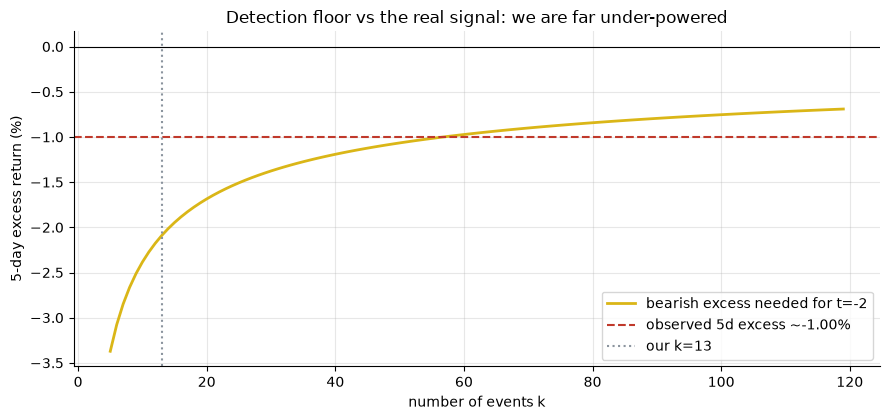

at k=13 you need ~-2.1% bearish excess for t=-2; observed ~-1.00% -> under-powered by ~2.1x


In [7]:
if HAVE_REAL:
    cr = st.event_returns(F['SPY'], EVENTS, 5); sd = cr.std(ddof=1)
    obs_excess = (R['spy'][5][2]-R['spy'][5][4])/100
else:
    sd = 0.035; obs_excess = (R['spy'][5][2]-R['spy'][5][4])/100
ks = np.arange(5, 120)
min_detectable = -2.0 * sd / np.sqrt(ks)   # bearish excess needed for t=-2 (base SE ~0)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='bearish excess needed for t=-2')
ax.axhline(obs_excess*100, c=RED, ls='--', label=f'observed 5d excess ~{obs_excess*100:+.2f}%')
ax.axvline(R['n_events'], c=GREY, ls=':', label=f"our k={R['n_events']}")
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('number of events k'); ax.set_ylabel('5-day excess return (%)')
ax.set_title('Detection floor vs the real signal: we are far under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = -2.0*sd/np.sqrt(R['n_events'])
print(f'at k={R["n_events"]} you need ~{need*100:.1f}% bearish excess for t=-2; observed ~{obs_excess*100:+.2f}% -> under-powered by ~{abs(need/obs_excess):.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable bearish excess**; the red line is what we actually see at 5 days. They don't meet until $k$ is many times larger than the repo-spike event list will ever deliver — and even then the effect has *flipped to positive* by 20 days. There is no sizing, no horizon, no cost assumption that manufactures a tradable warning from a dozen confounded events — **the rarity that makes "watch the repo market" sound prophetic is exactly what makes it untestable and untradable.**

## 7 · Going further

- **The slow cousin.** [Study 115 — Credit-Spreads](../../115-credit-spreads/): whether the credit *cycle* (not the overnight plumbing) carries a forward warning — the fairer test of "stress predicts risk-off."
- **Another stress gauge.** [Study 111 — VIX-Term-Structure](../../111-vix-term-structure/) — a different flashing light, same base-rate-and-frequency question.
- **The backdrop.** [Study 317 — Fed-Balance-Sheet](../../317-fed-balance-sheet/) — reserves / QT, the reason repo gets tight at quarter-ends.
- **Do it properly.** Pull the real NY-Fed SOFR percentiles / GC-repo series, define a mechanical stress threshold (e.g. SOFR-minus-IORB > X bp), and re-run; the event count and the exact dates change, the power-and-confounding problem does not.

*The reproducible core is offline and deterministic; the repo-stress input is an explicit hardcoded event list. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*